# Assignment 2 Anomaly Detection in Time Series Data

## 1. Frame the Problem

### **1.1 Business Objective**
Detect anomalies in water pump sensor data to prevent failures.

### **1.2 Use Case**
- Monitor real-time sensor data.  
- Detect and alert on anomalies.  
- Reduce downtime and maintenance costs.  

### **1.3 Problem Framing**
- **Unsupervised learning** (no labels).  
- Models: **Isolation Forest, Bayesian Gaussian Mixture, K-Means**.  

### **1.4 Evaluation**
The following metrics will be used to assess anomaly detection performance:

- **Precision**: Measures how many of the detected anomalies are actually correct.  
  $$ \text{Precision} = \frac{TP}{TP + FP} $$

- **Recall**: Measures how many actual anomalies were successfully detected.  
  $$ \text{Recall} = \frac{TP}{TP + FN} $$

- **F1-score**: Harmonic mean of precision and recall, balancing both.  
  $$ F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

Where:  
- **TP** = True Positives (correctly detected anomalies)  
- **FP** = False Positives (incorrectly flagged as anomalies)  
- **FN** = False Negatives (missed anomalies)  

And also **t-SNE visualization** for clustering models.  

### **1.6 Assumptions**
- Sensor data is reliable.  
- Anomalies are rare but significant.   


## 2 Get the Data

### **2.1 About the Dataset**
This dataset consists of **three main groups of data**:
- **Timestamp data**: Time-based records of machine operation.
- **Sensor data (52 series)**: Raw sensor values tracking machine performance.
- **Machine status**: The target variable `machine_status` indicating machine condition: `NORMAL`, `BROKEN` and `RECOVERING`.


The target values will only be used for the evaluation since this is an **Unsupervised ML Project** and for simplicity we want to categorize **both** `BROKEN` and `RECOVERING` as anomolies. 

### **2.2 Load the Dataset**

We need to understand the structure of the dataset before proceeding with preprocessing.  
Key aspects to check:
- Number of features (timestamps + 52 sensors + machine status).
- Data types and missing values.
- Unique values in the **machine_status** column.

In [1]:
import pandas as pd

# Load dataset
file_path = "dataset/sensor.csv"
df = pd.read_csv(file_path)

# Display first few rows
df.head()


,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


### **2.3 Data Overveiw**

A summary of the dataset structure, including feature names, data types. 

In [2]:
print("Dataset Overview: ")
# Check dataset structure
df.info()

# Summary statistics
df.describe()

Dataset Overview: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      220320 non-null  int64  
 1   timestamp       220320 non-null  object 
 2   sensor_00       210112 non-null  float64
 3   sensor_01       219951 non-null  float64
 4   sensor_02       220301 non-null  float64
 5   sensor_03       220301 non-null  float64
 6   sensor_04       220301 non-null  float64
 7   sensor_05       220301 non-null  float64
 8   sensor_06       215522 non-null  float64
 9   sensor_07       214869 non-null  float64
 10  sensor_08       215213 non-null  float64
 11  sensor_09       215725 non-null  float64
 12  sensor_10       220301 non-null  float64
 13  sensor_11       220301 non-null  float64
 14  sensor_12       220301 non-null  float64
 15  sensor_13       220301 non-null  float64
 16  sensor_14       220299 non-null  floa

,Unnamed: 0,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
count,220320.000000,210112.000000,219951.000000,220301.000000,220301.000000,220301.000000,220301.000000,215522.000000,214869.000000,215213.000000,...,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,143303.000000,204937.000000
mean,110159.500000,2.372221,47.591611,50.867392,43.752481,590.673936,73.396414,13.501537,15.843152,15.200721,...,35.453455,43.879591,42.656877,43.094984,48.018585,44.340903,150.889044,57.119968,183.049260,202.699667
std,63601.049991,0.412227,3.296666,3.666820,2.418887,144.023912,17.298247,2.163736,2.201155,2.037390,...,10.259521,11.044404,11.576355,12.837520,15.641284,10.442437,82.244957,19.143598,65.258650,109.588607
min,0.000000,0.000000,0.000000,33.159720,31.640620,2.798032,0.000000,0.014468,0.000000,0.028935,...,22.135416,24.479166,25.752316,26.331018,26.331018,27.199070,26.331018,26.620370,27.488426,27.777779
25%,55079.750000,2.438831,46.310760,50.390620,42.838539,626.620400,69.976260,13.346350,15.907120,15.183740,...,32.812500,39.583330,36.747684,36.747684,40.509258,39.062500,83.912030,47.743060,167.534700,179.108800
50%,110159.500000,2.456539,48.133678,51.649300,44.227428,632.638916,75.576790,13.642940,16.167530,15.494790,...,35.156250,42.968750,40.509260,40.219910,44.849540,42.534720,138.020800,52.662040,193.865700,197.338000
75%,165239.250000,2.499826,49.479160,52.777770,45.312500,637.615723,80.912150,14.539930,16.427950,15.697340,...,36.979164,46.614580,45.138890,44.849540,51.215280,46.585650,208.333300,60.763890,219.907400,216.724500
max,220319.000000,2.549016,56.727430,56.032990,48.220490,800.000000,99.999880,22.251160,23.596640,24.348960,...,374.218800,408.593700,1000.000000,320.312500,370.370400,303.530100,561.632000,464.409700,1000.000000,1000.000000


### **2.4 Storage**
- Check dataset size and storage needs.

In [3]:
# Check dataset size in MB
dataset_size_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Dataset size: {dataset_size_mb:.2f} MB")

Dataset size: 114.99 MB


### **2.5 Prepare Data for Training**

In [4]:
# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

### **2.6 Train/Test Strategy for Unsupervised Learning**

Although this is an unsupervised task, we will evaluate the model’s ability to detect real anomalies.  
Therefore, we’ll perform an 80/20 train/test split **after data preparation**.  
Labels will not be used for training, only for performance evaluation.


## 3. Explore the Data



In this step, we explore the structure, quality, and characteristics of the dataset to better understand the features before applying any models.  
Since this is an **unsupervised anomaly detection task**, we focus on patterns in the data itself without relying on labels during training.

### **3.1 Class Distribution (for reference only)**

Although we're not using `machine_status` during model training, it's helpful to understand the distribution of conditions to later evaluate model performance.


In [5]:
# Check class distribution
print(df['machine_status'].value_counts())

machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64


### **3.2 Visualize Missing Data**

A heatmap helps reveal patterns of missing data, which can inform decisions about feature removal or imputation.

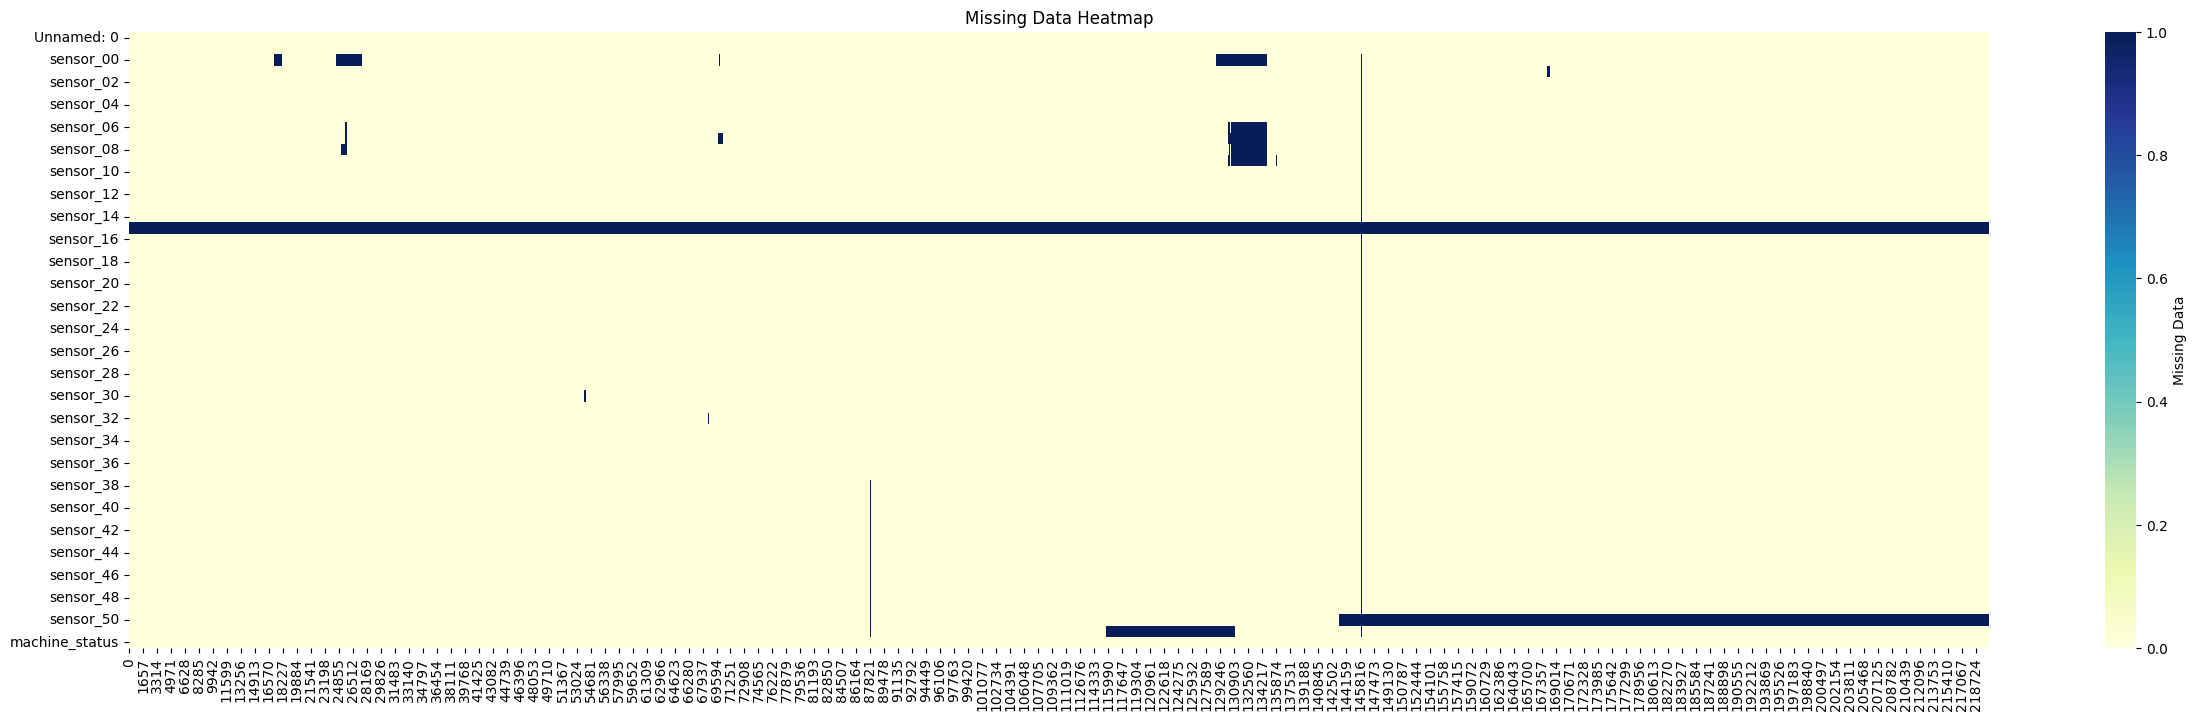

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing Missing Data with a Heatmap
plt.figure(figsize=(30, 8))
sns.heatmap(df.isna().transpose(), cmap="YlGnBu", cbar_kws={'label': 'Missing Data'})
plt.title('Missing Data Heatmap')
plt.show()

### **3.3 Sensor Data Distributions**

We plot 9 sensor columns to get a broader understanding of their distributions.  
This helps detect skew, outliers, or abnormal ranges that might impact the model.




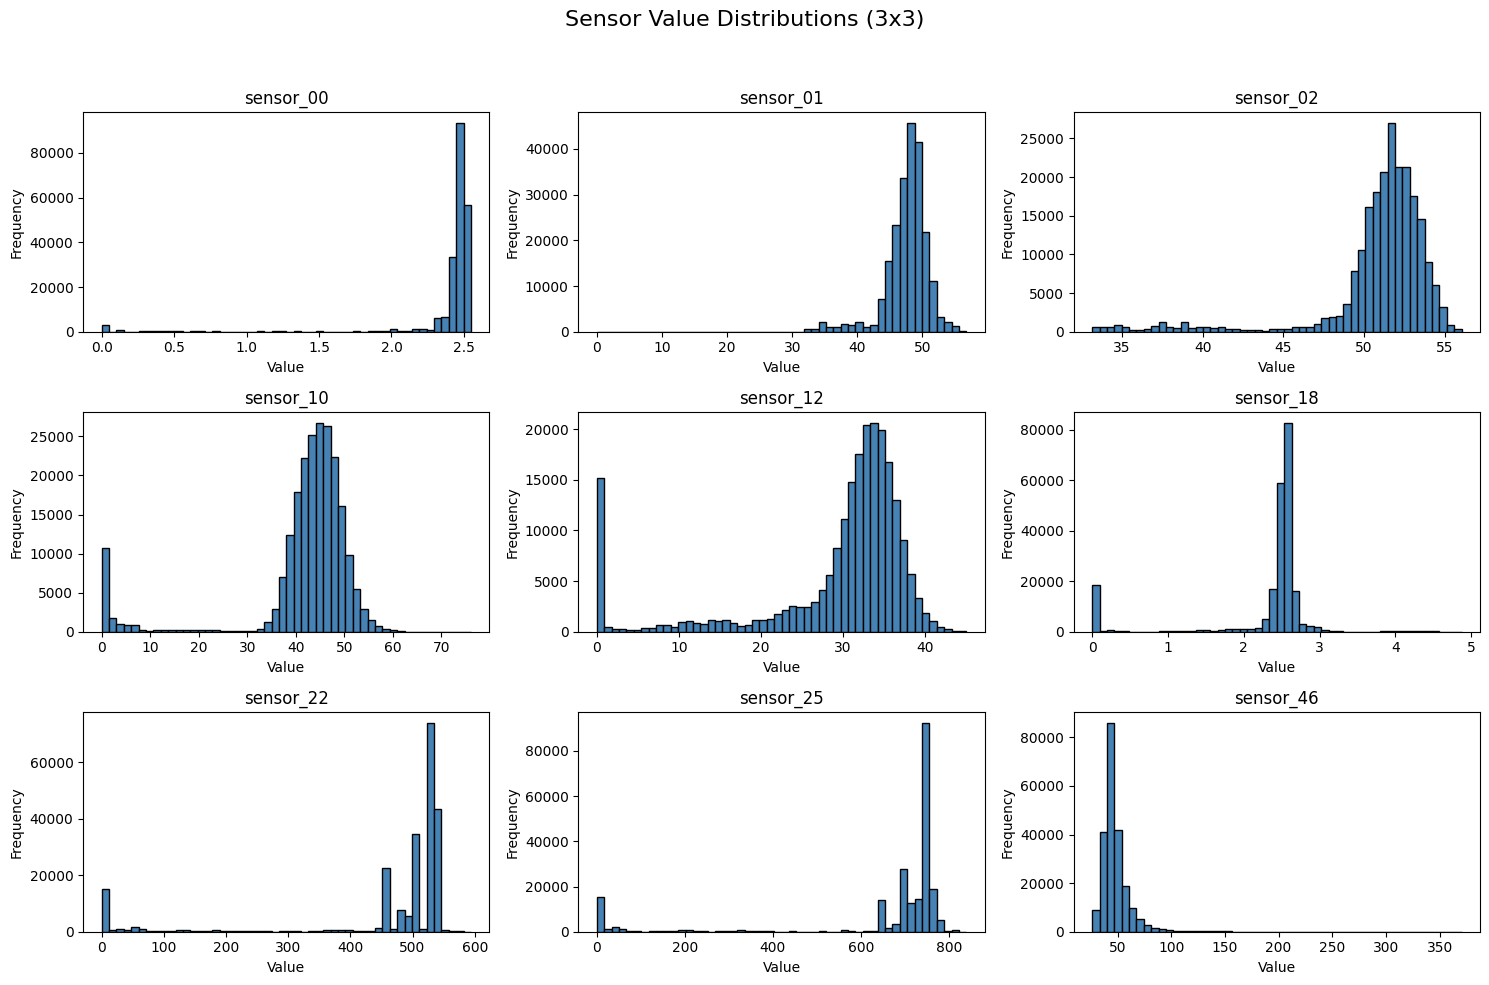

In [7]:
# Select 9 sensors to visualize
sensor_cols = ['sensor_00', 'sensor_01', 'sensor_02',
               'sensor_10', 'sensor_12', 'sensor_18',
               'sensor_22', 'sensor_25', 'sensor_46']

# Create 3x3 plot
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Sensor Value Distributions (3x3)", fontsize=16)

# Plot each sensor
for i, sensor in enumerate(sensor_cols):
    row, col = divmod(i, 3)
    df[sensor].plot(kind='hist', bins=50, ax=axes[row, col], title=sensor, color='steelblue', edgecolor='black')
    axes[row, col].set_xlabel("Value")
    axes[row, col].set_ylabel("Frequency")

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the suptitle
plt.show()



### **3.4 Time-Series Trends**
A time-series plot can reveal sudden spikes or shifts that indicate anomalies.


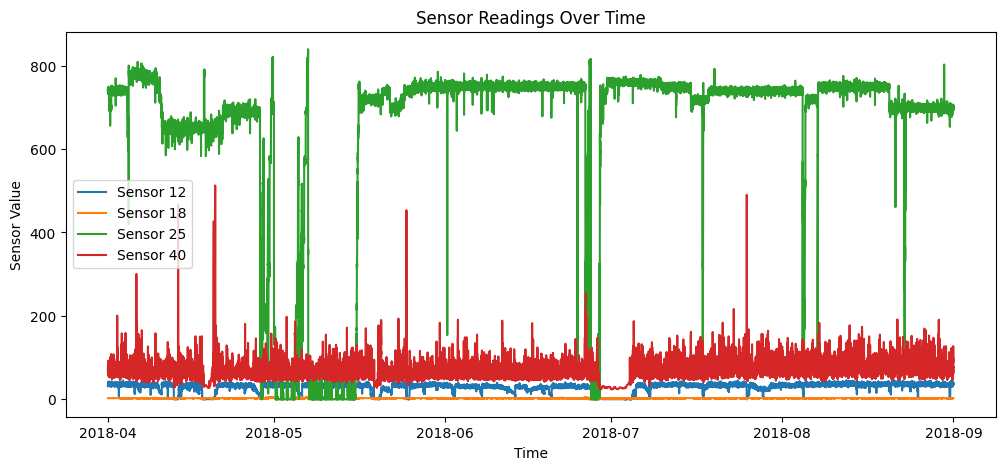

In [8]:
# **Plot time-series trends for selected sensors**
plt.figure(figsize=(12, 5))
plt.plot(df['timestamp'], df['sensor_12'], label="Sensor 12")
plt.plot(df['timestamp'], df['sensor_18'], label="Sensor 18")
plt.plot(df['timestamp'], df['sensor_25'], label="Sensor 25")
plt.plot(df['timestamp'], df['sensor_40'], label="Sensor 40")

plt.xlabel("Time")
plt.ylabel("Sensor Value")
plt.legend()
plt.title("Sensor Readings Over Time")
plt.show()


### **3.5 Correlation Between Sensors**
Highly correlated sensors may be redundant and can be removed to reduce dimensionality without losing information.


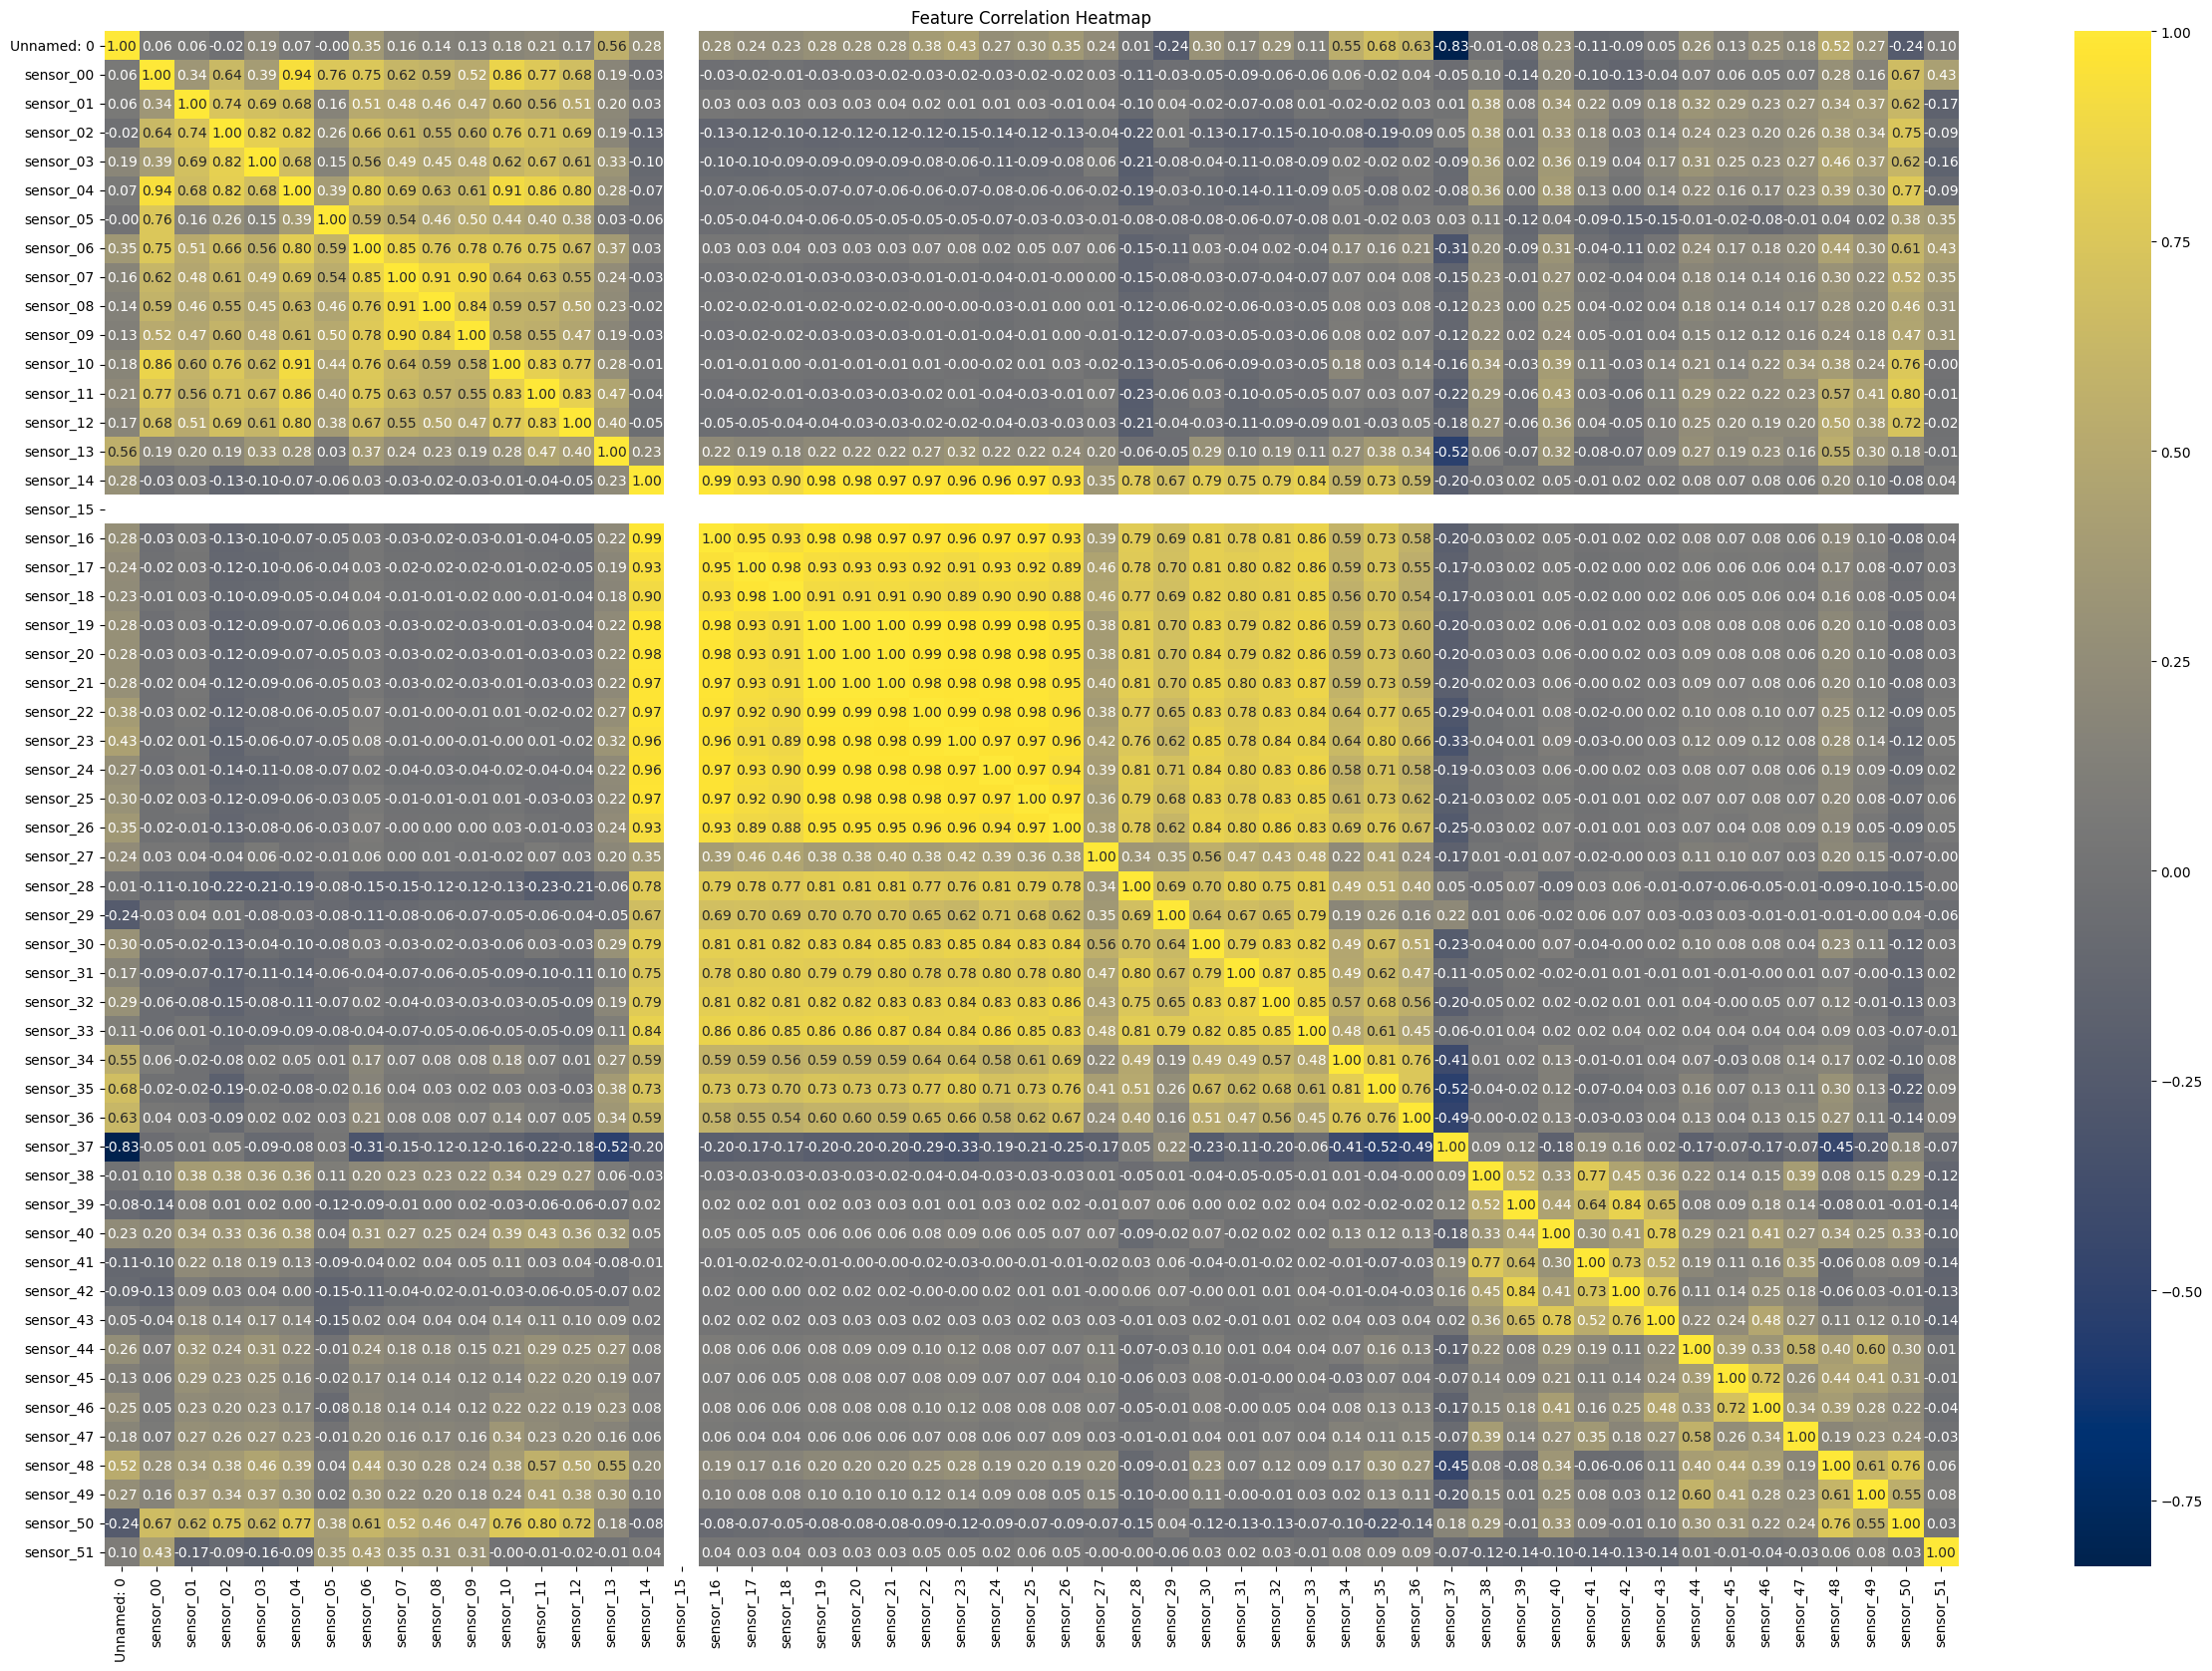

In [9]:
# Drop non-numeric columns
df_numeric = df.select_dtypes(include=['number'])

# **Compute correlation matrix**
corr_matrix = df_numeric.corr()

# Plot correlation heatmap
plt.figure(figsize=(30, 20))
sns.heatmap(corr_matrix,  annot=True, cmap='cividis', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


### **3.6 Summary of Findings and Observations**

During the data exploration phase, we made several key observations that inform how we prepare the data:

- **Missing data** is present in several sensors (as shown in the heatmap).
- **Sensor value distributions vary** — some are skewed or contain extreme values, indicating the need for scaling or transformation.
- **Time-series trends** reveal shifts and spikes, which may correspond to anomalies or machine state transitions.
- **High correlation between sensors** was detected — many show **more than 99% correlation** with at least one other sensor. These may be redundant and can be removed or compressed to reduce dimensionality.

These findings guide our decisions in **data cleaning, feature scaling, and feature selection** before training anomaly detection models.


## **4. Prepare the Data for Training**

Based on the insights from the data exploration phase, we now prepare the dataset for anomaly detection.  
The goal is to clean, reduce, and transform the data so that models can focus on meaningful patterns without being misled by noise, redundancy, or scale differences.

### **Key steps in this section:**
- Drop irrelevant columns (e.g., timestamp, sensors with a lot of missing data)
- Handle missing values
- Remove highly correlated/redundant features
- **Split the dataset chronologically into train and test sets**
- **Fit scaling only on the training set, then apply to test set**

This approach ensures the data is consistent, clean, and avoids **data leakage**, preserving the integrity of model evaluation in an unsupervised setting.


### **4.1 Handling Missing Data**
Some sensors have a significant amount of missing values. We remove the ones that are completely empty or have excessive missing data.


In [10]:
# Drop columns with excessive missing values (if they exist)
df = df.drop(['sensor_15', 'sensor_00', 'sensor_50', 'sensor_51', 'NUM', 'timestamp'],
             axis=1,
             errors='ignore')

# Confirm that the columns are removed
print("Remaining columns after dropping:", df.columns)


Remaining columns after dropping: Index(['Unnamed: 0', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04',
       'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09',
       'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14',
       'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
       'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25',
       'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30',
       'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35',
       'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40',
       'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45',
       'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'machine_status'],
      dtype='object')


### **4.2 Removing Redundant Sensors**
To reduce redundancy:
- We **keep one sensor** from each highly correlated pair (correlation > 0.98).
- The sensor to keep is selected arbitrarily (but we can refine this later if needed).


In [11]:
# Compute absolute correlation matrix for numeric features
corr_matrix = df.select_dtypes(include=["number"]).corr()
corr_matrix_abs = corr_matrix.abs()

# Identify sensors to keep (remove highly correlated ones > 0.98)
selected_columns = set()
for column in corr_matrix_abs.columns:
    if column not in selected_columns:
        selected_columns.add(column)
        correlated = corr_matrix_abs.index[corr_matrix_abs[column] > 0.99].tolist()
        for sensor in correlated:
            if sensor != column:
                selected_columns.discard(sensor)

# Create a list of columns to keep and update df
df = df[list(selected_columns) + ["machine_status"]]  # Add label back for eval later

# Print summary
removed_sensors = set(corr_matrix.columns) - selected_columns
print(f"Removed {len(removed_sensors)} highly correlated sensor columns: {removed_sensors}")
print(f"New shape of df: {df.shape}")


Removed 3 highly correlated sensor columns: {'sensor_19', 'sensor_20', 'sensor_14'}
New shape of df: (220320, 47)


### **4.3 Handling Missing Data Part 2**
To ensure consistency, we fill missing sensor values using **forward fill (`ffill`)**, which propagates the last known value forward.

This method is useful for **time-series data** where sensor readings are continuous and missing values can be assumed to follow previous trends.

In [12]:
# Fill missing values using forward fill
df.fillna(method='ffill', inplace=True)

# Confirm that missing values are filled
print("Remaining missing values:\n", df.isnull().sum().sum())  # Should be 0 if fully filled

Remaining missing values:
 0


/var/folders/yh/k881ccjj4qjb55qnwn5y8l4c0000gn/T/ipykernel_90707/1022009526.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


### **4.4 Splitting Data into Train and Test Sets**

To avoid **data leakage** in a time-series context, we perform a chronological split:
- **70% for training**
- **30% for testing**
This ensures that the model only sees past data and is evaluated on future data — mimicking a real deployment scenario.

To evaluate model predictions later, we convert the `machine_status` column into binary labels:
- `NORMAL` → 0 (normal)
- `RECOVERING`, `BROKEN` → 1 (anomaly)

This binary label is only used for evaluation after training, not during model fitting or tuning.



In [13]:
# Define 60/40 chronological split
split_index = round(len(df) * 0.7)

train = df.iloc[:split_index, :]
test = df.iloc[split_index:, :]

# Convert 'machine_status' to binary anomaly labels for evaluation
# NORMAL → 0 (normal), RECOVERING or BROKEN → 1 (anomaly)
y_test_binary = test["machine_status"].apply(lambda x: 0 if x == "NORMAL" else 1)


# Check resulting shapes
print(f"Training set shape: {train.shape}")
print(f"Test set shape: {test.shape}")


Training set shape: (154224, 47)
Test set shape: (66096, 47)


### **4.5 Scaling Sensor Data**

To standardize sensor readings:
- We apply **Z-score normalization** using `StandardScaler()`.
- This ensures each feature has **zero mean** and **unit variance**.
- It prevents sensors with larger ranges from dominating the anomaly detection model.
- The scaler is **fit only on the training set** to avoid data leakage.


In [14]:
from sklearn.preprocessing import StandardScaler

# Select only numeric features (exclude label)
feature_cols = train.select_dtypes(include=["number"]).columns

# Separate feature matrices
X_train = train[feature_cols]
X_test = test[feature_cols]

# Apply Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Apply same scaler to test set


### **4.6 Summary of the Processed Data**

We have now completed all major preprocessing steps:

- Handled missing values using forward fill  
- Removed sensor columns with excessive missing data  
- Dropped highly correlated features (>98% correlation)  
- Performed a chronological **80/20 train-test split**  
- Applied **Z-score scaling** on sensor values using `StandardScaler` (fitted only on training data)

The data is now ready for unsupervised anomaly detection.  
We skip further inspection here, as the processed data has already been reviewed during earlier steps.


## 5. Train the Model

We now apply unsupervised machine learning techniques to detect anomalies in the sensor data.

### **Modeling Plan**
- We use **unsupervised learning**, meaning no labels are used during training.
- Models to be tested:
  - **Isolation Forest** – tree-based anomaly detector
  - **Bayesian Gaussian Mixture** – probabilistic density-based model
  - **K-Means Clustering** – distance-based anomaly detector

These models will be trained on the **scaled training set**, and their anomaly predictions will be compared to the `machine_status` labels **only for evaluation purposes**.


### **5.1 Training Isolation Forest**

We train an **Isolation Forest** to detect anomalies in the scaled sensor data.  
This unsupervised model isolates data points using random decision trees and is well-suited for high-dimensional, unlabeled datasets.

The model is trained on `X_train_scaled`. 

In [15]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest on scaled training data
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
iso_forest.fit(X_train_scaled)

# Predict anomalies on test set
y_pred_iso = iso_forest.predict(X_test_scaled)

# Convert predictions: -1 → 1 (anomaly), 1 → 0 (normal)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]


### **5.2 Training Bayesian Gaussian Mixture**

We train a **Bayesian Gaussian Mixture Model (BGMM)** to detect anomalies in the scaled sensor data.  
This unsupervised model fits a probabilistic distribution to the data using a Dirichlet Process prior, allowing it to adapt the number of active components.

The model is trained on `X_train_scaled`, and samples with low likelihoods under the model are considered anomalies.

To reduce dimensionality and suppress noise, we apply **Principal Component Analysis (PCA)** to the scaled training data before training the BGMM.  
We retain **95% of the variance**, ensuring a good trade-off between compression and information preservation.

The PCA-transformed features are used for both training and scoring on the test set.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture
import numpy as np

# Step 1: Apply PCA
pca = PCA(n_components=0.95, svd_solver = 'full', random_state=42)  # Keep 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Step 2: Train BGMM on PCA-transformed training data
bgmm = BayesianGaussianMixture(
    n_components=3,
    covariance_type='diag',
    weight_concentration_prior_type='dirichlet_process',
    weight_concentration_prior=0.1,
    init_params='kmeans',
    random_state=42
)
bgmm.fit(X_train_pca)

# Step 3: Score samples in the test set
log_likelihood = bgmm.score_samples(X_test_pca)

# Step 4: Predict anomalies based on log-likelihood threshold (bottom 1%)
threshold = np.percentile(log_likelihood, 1)
y_pred_gmm = (log_likelihood < threshold).astype(int)


We use the **log-likelihood** of each sample under the BGMM model as an anomaly score.  
Samples with the **lowest 5% likelihoods** are flagged as anomalies.


### **5.3 Training K-Means Clustering**

We train a **K-Means clustering** model to detect anomalies in the sensor data.  
K-Means partitions the dataset into clusters by minimizing the distance to cluster centroids.  
Although not designed specifically for anomaly detection, K-Means can be used by identifying points that are **far from any cluster center**.

The model is trained on `X_train_scaled`. We compute distances to cluster centers in the test set and flag the most distant samples as anomalies.

Before applying K-Means, we use **PCA** to reduce the dimensionality of the scaled data.  
This helps improve clustering performance and reduce noise in high-dimensional space.

We retain **95% of the variance**, and use the PCA-transformed features for both training and prediction.

In [17]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np

# Step 1: Apply PCA
pca = PCA(n_components=0.95, svd_solver = 'full', random_state=42)  # Keep 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Step 2: Train K-Means on PCA-transformed training data
kmeans = KMeans(n_clusters=3,init= "k-means++", random_state=42) # n_clusters found by the elbow method
kmeans.fit(X_train_pca)

# Step 4: Predict distances to the nearest cluster center (anomaly score)
distances = kmeans.transform(X_test_pca)
min_distances = np.min(distances, axis=1)

# Step 4: Predict anomalies: top 1% of points with highest distance
threshold = np.percentile(min_distances, 99)
# Predict anomalies: 1 = anomaly, 0 = normal
y_pred_kmeans = (min_distances > threshold).astype(int)


We use the distance to the nearest cluster center as an anomaly score.
Points in the top 5% most distant are flagged as anomalies.

#### **5.3.2 Selecting Number of Clusters (Inertia Method)**

We test different values of `k` (number of clusters) and plot **inertia** to evaluate cluster compactness.  
Lower inertia indicates tighter clusters — we look for an **elbow point** to guide `k` selection.


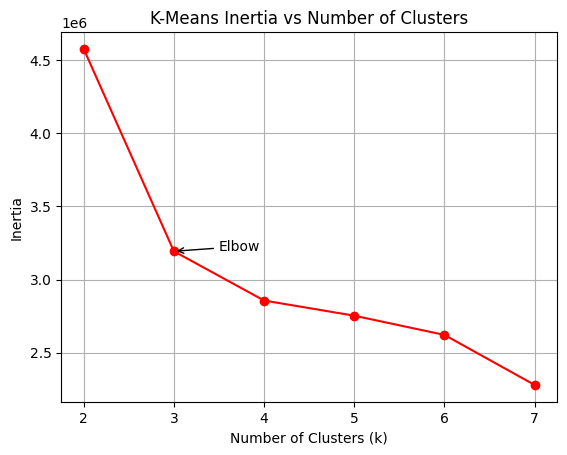

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Inertia scores for k = 2 to 7
k_vals = range(2, 8)
inertia = [KMeans(n_clusters=k, random_state=42).fit(X_train_pca).inertia_ for k in k_vals]

# Plot with elbow annotation
plt.plot(k_vals, inertia, marker="o", color="red")
plt.title("K-Means Inertia vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)

# Annotate elbow (e.g. k=3)
elbow_k = 3
elbow_inertia = inertia[k_vals.index(elbow_k)]
plt.annotate("Elbow", xy=(elbow_k, elbow_inertia), xytext=(elbow_k + 0.5, elbow_inertia + 5000),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.show()

**Note:** The elbow plot does not show a very clear "elbow" point, which makes it hard to determine the optimal number of clusters.  
We proceed with `n = 3`, a commonly used default for anomaly detection, which balances model simplicity and separation.


### **5.4 Evaluate Model Predictions**

To assess model performance, we use common classification metrics:

- **Precision**: How many predicted anomalies are actually correct  
- **Recall**: How many true anomalies were detected  
- **F1-score**: Harmonic mean of precision and recall, balancing both  

Labels are only used here for **final evaluation**, not for training or tuning.


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate an unsupervised model using classification metrics.
    
    Parameters:
    - model_name (str): Name of the model
    - y_true (array-like): True binary anomaly labels (0 = normal, 1 = anomaly)
    - y_pred (array-like): Predicted anomaly labels (0 = normal, 1 = anomaly)
    """
    print(f"\n=== Evaluation Report: {model_name} ===")
    
    # Print classification metrics
    print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"]))
    
    # Display confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
    disp.plot(cmap="Oranges")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()



=== Evaluation Report: Isolation Forest ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     66020
     Anomaly       0.25      0.71      0.37        76

    accuracy                           1.00     66096
   macro avg       0.62      0.85      0.68     66096
weighted avg       1.00      1.00      1.00     66096



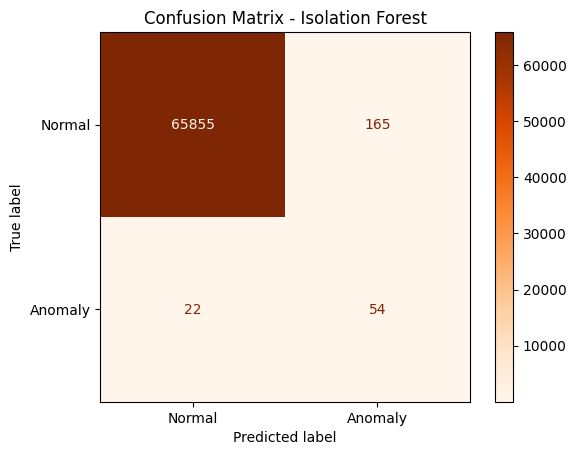


=== Evaluation Report: Bayesian GMM ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     66020
     Anomaly       0.09      0.75      0.15        76

    accuracy                           0.99     66096
   macro avg       0.54      0.87      0.57     66096
weighted avg       1.00      0.99      0.99     66096



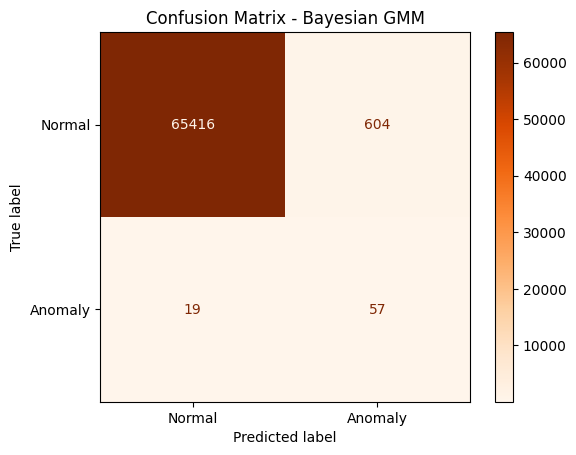


=== Evaluation Report: K-Means ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     66020
     Anomaly       0.08      0.72      0.15        76

    accuracy                           0.99     66096
   macro avg       0.54      0.86      0.57     66096
weighted avg       1.00      0.99      0.99     66096



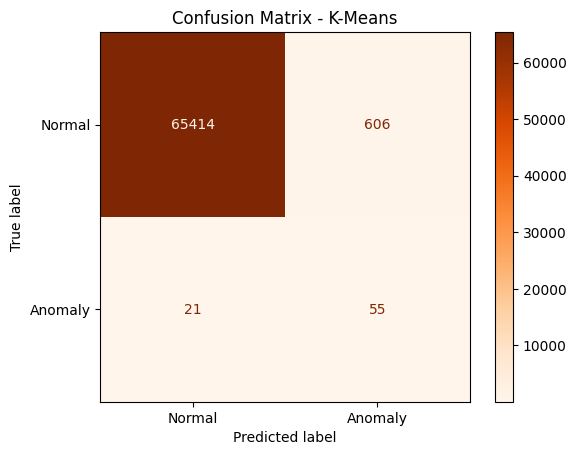

In [20]:
evaluate_model("Isolation Forest", y_test_binary, y_pred_iso)
evaluate_model("Bayesian GMM", y_test_binary, y_pred_gmm)
evaluate_model("K-Means", y_test_binary, y_pred_kmeans)

### **5.5 Evaluation Summary**

The evaluation highlights significant challenges in detecting anomalies with unsupervised methods:

- **Isolation Forest** had the best anomaly detection performance, but even this model achieved only 10% recall for anomalies—missing 90% of them.
- **Bayesian GMM** and **K-Means** misclassified some normal samples but barely detected any anomalies.
- All models reported high accuracy simply because the dataset is heavily **imbalanced**, with **anomalies making up less than 5%** of the test set.

As a result:
- Accuracy is misleading and does not reflect true model performance.
- Precision, recall, and F1-score for anomalies are **very low**, showing that the models struggle to detect rare events without supervision.


 **Model Performance Comparison**

| Model           | Accuracy | Precision (Anomaly) | Recall (Anomaly) | F1-Score (Anomaly) |
|----------------|----------|----------------------|------------------|---------------------|
| Isolation Forest | 0.99     | 0.25                 | 0.34             | 0.37                |
| Bayesian GMM     | 0.99     | 0.08                 | 0.75             | 0.15                |
| K-Means          | 0.99     | 0.09                 | 0.72             | 0.15                |


All models achieved high accuracy due to the dominance of the **normal class**, but failed to effectively detect anomalies.  
This confirms that accuracy alone is misleading in imbalanced anomaly detection tasks.


## **6. Fine-Tune the System**


### **6.1 Tune Preprocessing Choices (Unsupervised)**

Instead of tuning with labeled data, we treat **data transformation decisions** as hyperparameters.  
These include:

- Method of handling missing values (e.g. `ffill`)
- Correlation threshold for feature reduction 99%
- Feature scaling method (`StandardScaler` used here)

These were selected based on standard practice and domain assumptions, not label feedback.


- Tried changing the correlation theshold, which lead to less sensors being removed and it seemed that the F1 score improved for isolation forest. 

### **6.2 Ensemble of Unsupervised Models (Optional)**
We experiment with simple ensemble strategies to see if combining models improves anomaly detection.


In [ ]:
# OR: Flag as anomaly if any model does
ensemble_or = [1 if a or b or c else 0 for a, b, c in zip(y_pred_iso, y_pred_gmm, y_pred_kmeans)]

# AND: Flag as anomaly only if all models agree
ensemble_and = [1 if a and b and c else 0 for a, b, c in zip(y_pred_iso, y_pred_gmm, y_pred_kmeans)]

# Evaluate both
evaluate_model("Ensemble OR (All Models)", y_test_binary, ensemble_or)
evaluate_model("Ensemble AND (All Models)", y_test_binary, ensemble_and)

## 7. Present Your Solution

### **7.1 Summary**
We built an unsupervised anomaly detection pipeline to identify rare failures in water pump sensor data without using labels during training.

**Steps:**
- Cleaned and scaled the data, removed redundant features
- Trained Isolation Forest, Bayesian GMM, and K-Means
- Evaluated performance using true labels (test set only)
- Tested simple ensemble strategies (OR / AND)

### **7.2 Key Findings**
- All models achieved high accuracy but struggled to detect anomalies.
- Isolation Forest had the best recall, but performance was still low.
- Ensemble methods slightly improved recall (OR) or precision (AND).
- Accuracy was misleading due to class imbalance.

### **7.3 What Worked / Didn't**
- Isolation Forest performed relatively better.
- PCA helped reduce noise and dimensionality.
- GMM and K-Means failed to detect anomalies reliably.
- Elbow method was inconclusive for cluster selection.

### **7.4 Assumptions and Limitations**
- Assumed anomalies differ clearly in sensor data.
- No label-based tuning was used (fully unsupervised).
- Only numeric features were used.
- Anomalies (failures) were rare in the dataset.

### **7.6 Visualizing with t-SNE**

We used **t-SNE** to project the high-dimensional test data into 2D for visual inspection.

Plots show the same t-SNE transformation:
- Colored by **true labels** (`NORMAL` vs `ANOMALY`)
- Colored by each model’s **predicted labels**

This illustrates how well the models separated anomalies in latent space.  
Note: t-SNE is exploratory and sensitive to settings.



In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Apply t-SNE on test data
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_test_tsne = tsne.fit_transform(X_test_scaled)

# Step 2: Build DataFrames for plotting
tsne_true = pd.DataFrame(X_test_tsne, columns=['TSNE1', 'TSNE2'])
tsne_true['Label'] = y_test_binary.values

tsne_pred = pd.DataFrame(X_test_tsne, columns=['TSNE1', 'TSNE2'])
tsne_pred['Label'] = y_pred_iso  # or y_pred_kmeans, y_pred_gmm

# Step 3: Plot t-SNE with true labels
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=tsne_true, x='TSNE1', y='TSNE2', hue='Label',
                palette={0: 'green', 1: 'red'}, alpha=0.6)
plt.title("True Labels")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="True Label", labels=["Normal", "Anomaly"])

# Step 4: Plot t-SNE with model predictions
plt.subplot(1, 2, 2)
sns.scatterplot(data=tsne_pred, x='TSNE1', y='TSNE2', hue='Label',
                palette={0: 'green', 1: 'red'}, alpha=0.6)
plt.title("Predicted Labels Isolation Forest")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Predicted", labels=["Normal", "Anomaly"])

plt.suptitle("t-SNE Visualization of Test Data")
plt.tight_layout()
plt.show()


## **8. Launch**

In production, we’d:
- Hook the model into a live pipeline.
- Add monitoring to catch data drift or weird sensor inputs.
- Periodically retrain the model to stay updated with new data.

(But let’s be honest, none of this will happen unless someone gets paid to do it.)


# Conclusion & Recommendations

This project explored unsupervised anomaly detection on sensor data.  
While Isolation Forest showed the best performance, all models struggled to detect rare anomalies due to class imbalance and limited structure.

### Key Takeaways
- High accuracy was misleading — recall and precision for anomalies were low.
- PCA helped reduce noise; ensemble methods slightly improved results.
- Unsupervised models alone were not enough.

### Recommendations
- Try **semi-supervised** or **weakly supervised** methods.
- Consider **autoencoders** or time-based models.